In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

In [3]:
data1 = r"G:\My Drive\New_Working_Files\KNIME\CTU_2026\ML_Models\K_Mean.csv"
df = pd.read_csv(data1).replace("NoData",np.nan)
print(df.dtypes)

incident_id           object
customer_id           object
pain_in_mins           int64
breach_ageing          int64
ijs_score              int64
final_issue_type      object
sub_issue_type        object
current_queue_name    object
is_breached            int64
escalation_flag         bool
dtype: object


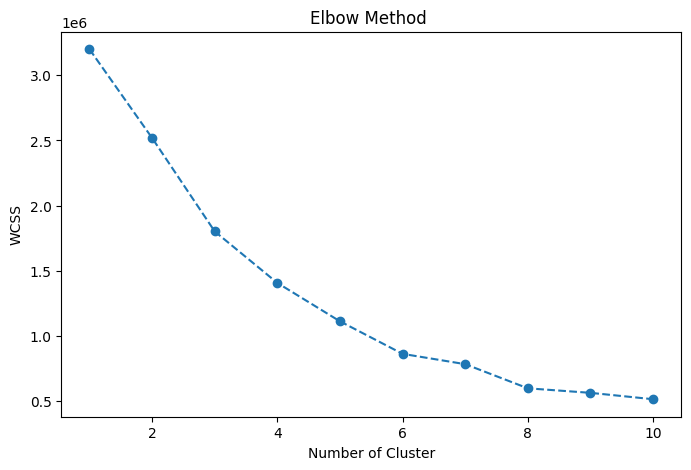

Cluster Profile
         pain_in_mins  breach_ageing    ijs_score  final_issue_type
Cluster                                                            
0           91.873600       0.009795     9.787464         23.350907
1          471.814909       0.024406    14.065649        159.575754
2         7019.259935      49.117345    92.275362         52.284245
3        65166.705882       1.088235   324.735294         55.382353
4         8535.317420       0.753371    50.169643         64.870627
5          941.784719       0.277352   385.768985         82.415294
6        73398.833333    1141.500000  1015.333333        114.666667
7        28739.011111     362.022222   813.333333         99.133333
8        12399.228782     127.792128   192.897909         58.435424
9         4213.669166       5.121837  1615.045923        104.685098


In [10]:
featues = ['pain_in_mins', 'breach_ageing', 'ijs_score', 'final_issue_type']
df_clust = df.dropna(subset=featues).copy()
if df_clust['final_issue_type'].dtype == 'object':
    df_clust['final_issue_type'] = LabelEncoder().fit_transform(df_clust['final_issue_type'].astype(str))

X = df_clust[featues]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title("Elbow Method ")
plt.xlabel("Number of Cluster")
plt.ylabel("WCSS")
plt.show()

k=3
kmeans =KMeans(n_clusters=i, init='k-means++', random_state=42)
df_clust['Cluster'] = kmeans.fit_predict(X_scaled)

cluster_summary = df_clust.groupby('Cluster')[featues].mean()
print("Cluster Profile")
print(cluster_summary)

    
    
    

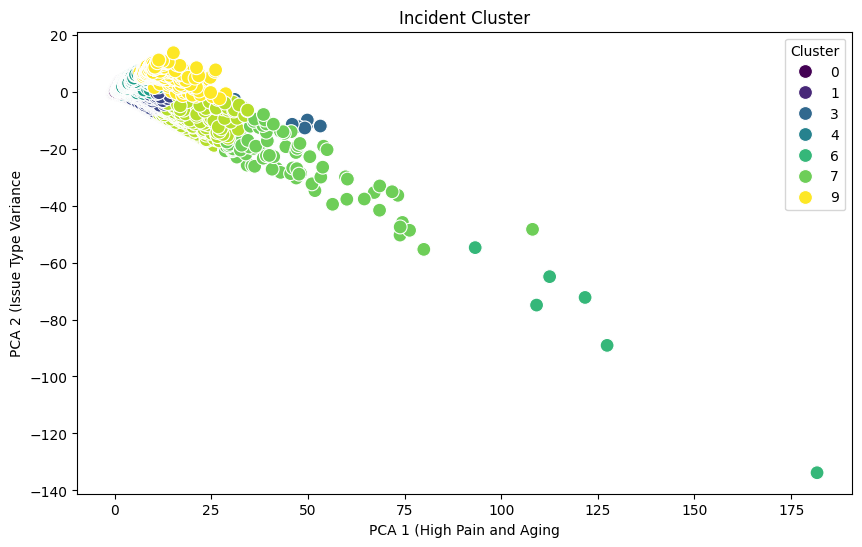

In [11]:
#PCA Cluster Visulizations

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df_clust['Cluster'], palette='viridis', s=100)
plt.title("Incident Cluster")
plt.xlabel("PCA 1 (High Pain and Aging")
plt.ylabel("PCA 2 (Issue Type Variance")
plt.legend(title='Cluster')
plt.show()

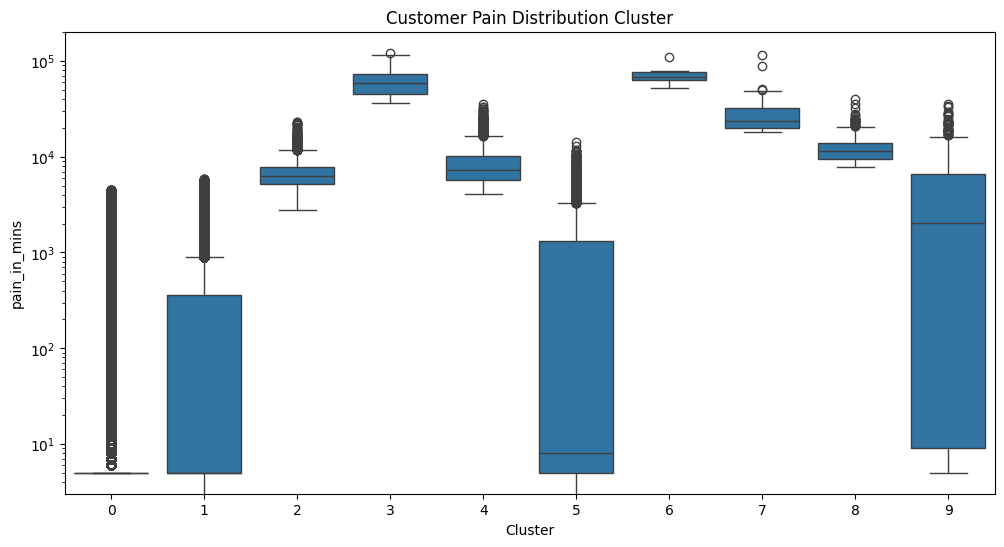

In [12]:
#Cluster Driver

plt.figure(figsize=(12,6))
sns.boxplot(x='Cluster', y='pain_in_mins', data=df_clust)
plt.title("Customer Pain Distribution Cluster")
plt.yscale('log')
plt.show()